## Experiment Results of Reinforcement Learning Approach 
(Goal Directed LSTM with Random Forest as a surrogate, Oracle -> lookup Table)

In [1]:
from reinforcement_appraoch import run_rl_experiment_lstm_rf
import pandas as pd

values = run_rl_experiment_lstm_rf()
results = pd.DataFrame(values)

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 0/100, Loss: 1.3472
Epoch 5/100, Loss: 1.2552
Epoch 10/100, Loss: 1.1928
Epoch 15/100, Loss: 1.1506
Epoch 20/100, Loss: 1.1223
Epoch 25/100, Loss: 1.1022
Epoch 30/100, Loss: 1.0877
Epoch 35/100, Loss: 1.0759
Epoch 40/100, Loss: 1.0681
Epoch 45/100, Loss: 1.0605
Epoch 50/100, Loss: 1.0530
Epoch 55/100, Loss: 1.0494
Epoch 60/100, Loss: 1.0433
Epoch 65/100, Loss: 1.0398
Epoch 70/100, Loss: 1.0357
Epoch 75/100, Loss: 1.0320
Epoch 80/100, Loss: 1.0284
Epoch 85/100, Loss: 1.0250
Epoch 90/100, Loss: 1.0218
Epoch 95/100, Loss: 1.0206
-------- Iteration 1/10 (temp=0.50) --------
Avg proposed: 0.3542, Avg real: 0.5383, Top 20% avg: 0.3885, Unique diverse: 11
Epoch 0/20, Loss: 1.4347
Epoch 5/20, Loss: 1.0256
Epoch 10/20, Loss: 0.8184
Epoch 15/20, Loss: 0.7208
-------- Iteration 2/10 (temp=0.58) --------
Avg proposed: 0.3709, Avg real: 0.5276, Top 20% avg: 0.3942, Unique diverse: 7
Epoch 0/20, Loss: 0.7074
Epoch 5/20, Loss: 0.5681
Epoch 10/20, Loss: 0.4942
Epoch 15/20, Loss: 0.4455
-------- 

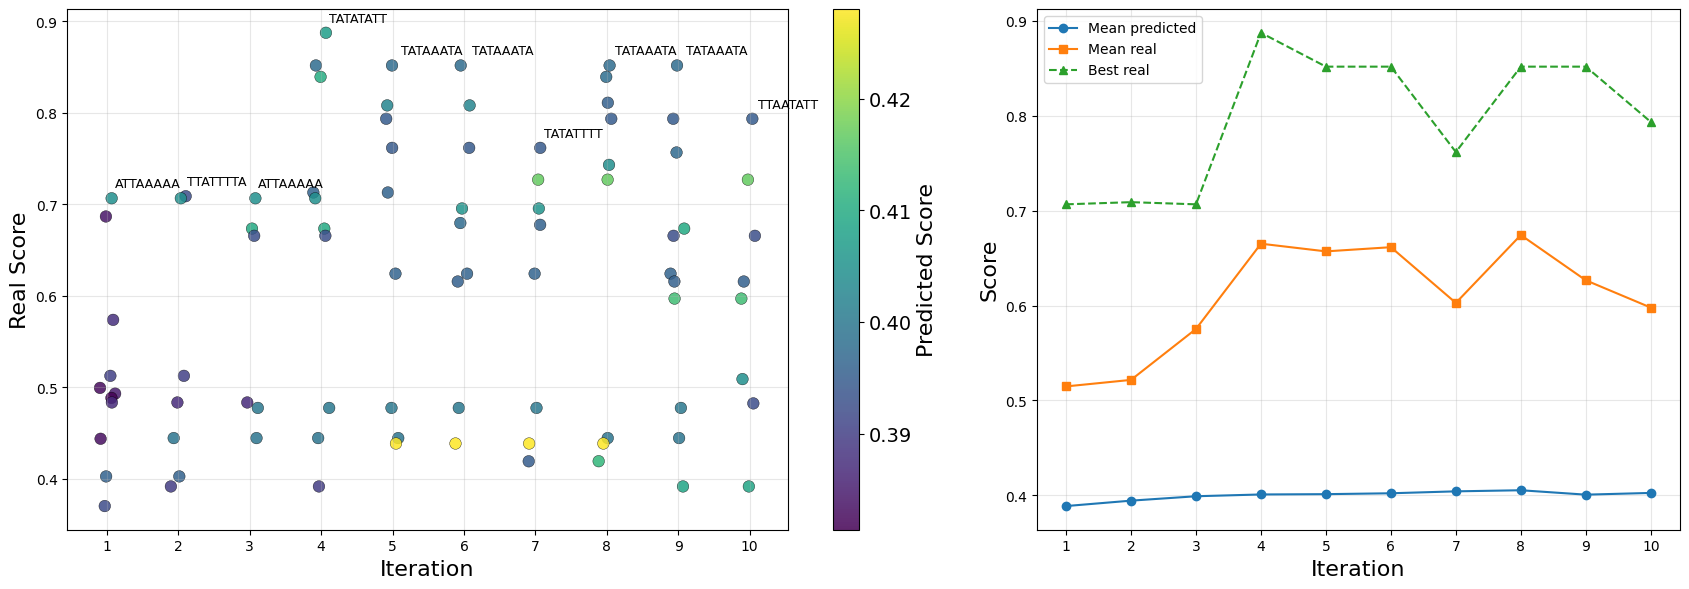

,iteration_plot,sequence,predicted_score,real_score
0,1,ATTAAAAA,[0.4044603805989027],0.706727
1,1,GTTGTTTA,[0.3840187285095453],0.686843
2,1,GAAAATAA,[0.38782021969556807],0.573816
3,1,TGTTTTTT,[0.3903594935685396],0.512627
4,1,TGTTAAAA,[0.3826190120726824],0.499443
...,...,...,...,...
83,10,ATTAAAAT,[0.39563899725675583],0.615749
84,10,TAATTGTT,[0.4134503473341465],0.597060
85,10,TCTTTTTT,[0.4044854247570038],0.509081
86,10,TAATAATT,[0.39222148001194],0.482518


,iteration_plot,n_sequences,mean_predicted,mean_real,best_predicted,best_real
0,1,11,[0.38848552663556557],0.514679,[0.4044603805989027],0.706727
1,2,7,[0.3941889916360378],0.521556,[0.4044603805989027],0.709005
2,3,6,[0.39882805048177644],0.575281,[0.409568352997303],0.706727
3,4,10,[0.40071653303504],0.665200,[0.4103375431895256],0.887663
4,5,9,[0.4010374401261409],0.657100,[0.42801354691386223],0.851936
5,6,9,[0.40196967328174243],0.661513,[0.42801354691386223],0.851936
6,7,8,[0.4040034381486476],0.602748,[0.42801354691386223],0.761854
7,8,9,[0.40515594547821415],0.674343,[0.42801354691386223],0.851936
8,9,11,[0.4005119301243262],0.626607,[0.4134503473341465],0.851936
9,10,8,[0.40233637567609554],0.597820,[0.4167461293935776],0.793654


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def mutation_to_sequence_label(seq, alphabet="ACGT"):
    arr = np.asarray(seq)

    if arr.ndim == 2:
        arr = arr.argmax(axis=-1)

    if arr.ndim == 1 and set(np.unique(arr)).issubset({0, 1}) and arr.size % len(alphabet) == 0:
        arr = arr.reshape(-1, len(alphabet)).argmax(axis=-1)

    if arr.ndim == 1 and np.issubdtype(arr.dtype, np.integer):
        arr = arr.astype(int)
        if arr.min() >= 0 and arr.max() < len(alphabet):
            return "".join(alphabet[index] for index in arr)

    return str(seq)


plot_df = results.copy()
plot_df["iteration_plot"] = plot_df["iteration"].astype(int)
if plot_df["iteration_plot"].min() == 0:
    plot_df["iteration_plot"] += 1

plot_df["sequence"] = plot_df["mutation"].apply(mutation_to_sequence_label)
plot_df = plot_df.sort_values(["iteration_plot", "real_score"], ascending=[True, False]).reset_index(drop=True)

summary_df = (
    plot_df
    .groupby("iteration_plot", as_index=False)
    .agg(
        n_sequences=("sequence", "nunique"),
        mean_predicted=("predicted_score", "mean"),
        mean_real=("real_score", "mean"),
        best_predicted=("predicted_score", "max"),
        best_real=("real_score", "max"),
    )
)

best_per_iteration = plot_df.loc[plot_df.groupby("iteration_plot")["real_score"].idxmax()].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.4, 1]})

rng = np.random.default_rng(42)
plot_df["iteration_jitter"] = plot_df["iteration_plot"] + rng.uniform(-0.12, 0.12, len(plot_df))

scatter = axes[0].scatter(
    plot_df["iteration_jitter"],
    plot_df["real_score"],
    c=plot_df["predicted_score"],
    cmap="viridis",
    s=70,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
)

for _, row in best_per_iteration.iterrows():
    axes[0].annotate(
        row["sequence"],
        (row["iteration_plot"], row["real_score"]),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=9,
    )

#axes[0].set_title("Found Sequences by Iteration")
axes[0].set_xlabel("Iteration", fontsize=16)
axes[0].set_ylabel("Real Score", fontsize=16)
axes[0].set_xticks(sorted(plot_df["iteration_plot"].unique()))
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Predicted Score", fontsize=16)
cbar.ax.tick_params(labelsize=14)

axes[1].plot(summary_df["iteration_plot"], summary_df["mean_predicted"], marker="o", label="Mean predicted")
axes[1].plot(summary_df["iteration_plot"], summary_df["mean_real"], marker="s", label="Mean real")
axes[1].plot(summary_df["iteration_plot"], summary_df["best_real"], marker="^", linestyle="--", label="Best real")
#axes[1].set_title("Score Trend per Iteration", fontsize=16)
axes[1].set_xlabel("Iteration", fontsize=16)
axes[1].set_ylabel("Score", fontsize=16)
axes[1].set_xticks(summary_df["iteration_plot"])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

display(plot_df[["iteration_plot", "sequence", "predicted_score", "real_score"]])
display(summary_df)


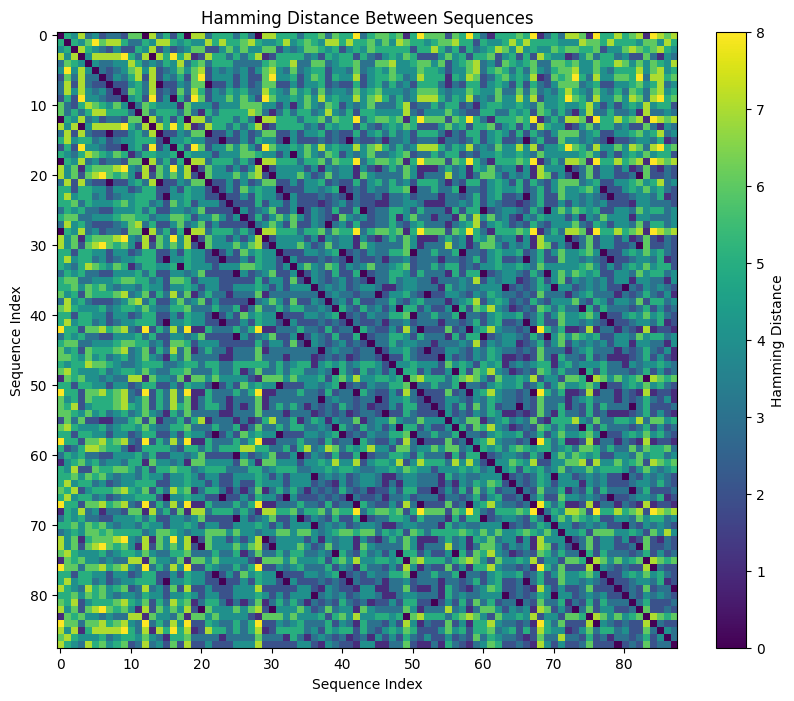

In [3]:
# Calculate hamming distance between all sequences and plot into a heatmap
from sklearn.metrics import pairwise_distances
sequences = plot_df["sequence"].tolist()
seq_array = np.array([list(seq) for seq in sequences])
distance_matrix = pairwise_distances(seq_array, metric=lambda x, y: sum(el1 != el2 for el1, el2 in zip(x, y)))
plt.figure(figsize=(10, 8))
plt.imshow(distance_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Hamming Distance")
plt.title("Hamming Distance Between Sequences")
plt.xlabel("Sequence Index")
plt.ylabel("Sequence Index")
plt.show()